# Black-76 N(d2) vs Polymarket Implied Probability

Research pipeline comparing risk-neutral probabilities implied by COMEX futures options (Black-76, N(d2)) against Polymarket "yes" prices on equivalent strike/expiry questions for Silver (SIU26) and Gold (GCQ26), H1 2026.

Pipeline: load Barchart option/futures CSVs -> back out implied vol -> compute N(d2) -> fetch matching Polymarket history -> merge on date/strike -> statistical tests (t-test, convergence regression, bid-ask spread, volatility-regime robustness) -> plots.

## 1. Imports & Configuration

Standard libraries, expiry dates for each contract, the risk-free rate, and the GCM26->GCQ26 roll cutoff used by the Gold basis adjustment below.

In [1]:
import os, re
from datetime import datetime
import warnings
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import brentq
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings('ignore')

# Folder containing all CSVs and this notebook
DATA_DIR = os.getcwd()

# ── Expiry dates ──────────────────────────────────────────────────────────────
# SIU26 (Sep 2026 Silver): last trading day = 3rd-last business day of Sep 2026
# GCQ26 (Aug 2026 Gold):   last trading day ≈ July 28 2026
EXPIRY_SI = datetime(2026, 9, 26)
EXPIRY_GC = datetime(2026, 7, 28)

RISK_FREE        = 0.045                      # 4.5% annualised
GC_BASIS_CUTOFF    = pd.Timestamp("2026-05-29") # GCM26 -> GCQ26 roll date
PM_RESOLUTION_DATE = pd.Timestamp("2026-06-30") # Polymarket market resolution date
                                                  # cap analysis here: post-resolution
                                                  # prices (0/1) would distort all deltas

print(f"DATA_DIR : {DATA_DIR}")
print(f"Expiry SI: {EXPIRY_SI.date()}   |  Expiry GC: {EXPIRY_GC.date()}")
print(f"Risk-free: {RISK_FREE:.1%}")
print(f"PM resolution cap: {PM_RESOLUTION_DATE.date()}")


DATA_DIR : C:\Users\Aidan\Desktop\Research paper Polymarket
Expiry SI: 2026-09-26   |  Expiry GC: 2026-07-28
Risk-free: 4.5%
PM resolution cap: 2026-06-30


## 2. Helper Functions

CSV loading, filename parsing for SI/GC strikes, and the Black-76 pricing / implied-vol / N(d2) functions used throughout the pipeline.

In [2]:
# ── Helper functions ───────────────────────────────────────────────────────────

def load_barchart_csv(path):
    """Read a Barchart CSV, dropping the 'Downloaded from …' footer row."""
    df = pd.read_csv(path)
    df = df[~df['Time'].astype(str).str.startswith('Downloaded')]
    df['Time'] = pd.to_datetime(df['Time'])
    df['Latest'] = pd.to_numeric(df['Latest'], errors='coerce')
    return df.sort_values('Time').reset_index(drop=True)


def discover_files(data_dir):
    """List the directory and return categorised file paths."""
    files = os.listdir(data_dir)

    opt_si  = sorted(f for f in files if re.match(r'siu\d+_\d+c_price-history', f))
    opt_gc  = sorted(f for f in files if re.match(r'gcq\d+_\d+c_price-history', f))

    und_si  = next((f for f in files if re.match(r'siu\d+_daily_historical', f)), None)
    und_gc  = next((f for f in files if re.match(r'gcq\d+_daily_historical', f)), None)
    und_gcm = next((f for f in files if re.match(r'gcm\d+_daily_historical', f)), None)

    print("SI option files :", opt_si)
    print("GC option files :", opt_gc)
    print("SI underlying   :", und_si)
    print("GC underlying   :", und_gc)
    print("GCM26 underlying:", und_gcm)
    return opt_si, opt_gc, und_si, und_gc, und_gcm


def parse_si_strike(filename):
    """
    Return strike in $/oz for a SIU26 option file.

    Barchart SI option filenames encode the strike in cents/oz (e.g. 7000 = $70).
    For strikes >= $100, Barchart drops the filename's trailing zero (e.g. $100 ->
    '1000' instead of '10000', $110 -> '1100' instead of '11000'). The full SI strike
    ladder only goes down to $60 (nominal 6000), so any nominal below that threshold
    must be one of these truncated $100+ strikes -- multiply by 10 to recover it.
    """
    m = re.search(r'siu\d+_(\d+)c_', filename)
    if not m:
        return None
    nominal = int(m.group(1))
    if nominal < 6000:
        nominal *= 10
    return nominal / 100.0


def parse_gc_strike(filename):
    """Return strike in $/oz for a GC option file (already in $/oz in filename)."""
    m = re.search(r'gcq\d+_(\d+)c_', filename)
    return float(m.group(1)) if m else None


# ── Black-76 (futures options) ─────────────────────────────────────────────────

def _d1d2(F, K, T, sigma):
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    return d1, d1 - sigma * np.sqrt(T)


def black76_call(F, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return np.exp(-r * max(T, 0)) * max(F - K, 0.0)
    d1, d2 = _d1d2(F, K, T, sigma)
    return np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))


def black76_nd2(F, K, T, r, sigma):
    """Risk-neutral probability P(F_T > K) = N(d2) under Black-76."""
    if T <= 0:
        return 1.0 if F > K else 0.0
    if np.isnan(sigma) or sigma <= 0:
        return np.nan
    _, d2 = _d1d2(F, K, T, sigma)
    return norm.cdf(d2)


def implied_vol(C_mkt, F, K, T, r):
    """Invert Black-76 via Brent's method. Returns NaN on failure."""
    if C_mkt <= 0 or T <= 0 or F <= 0 or K <= 0:
        return np.nan
    lower_bound = np.exp(-r * T) * max(F - K, 0.0)
    if C_mkt <= lower_bound + 1e-9:
        return np.nan
    try:
        return brentq(
            lambda s: black76_call(F, K, T, r, s) - C_mkt,
            1e-6, 30.0, xtol=1e-7, maxiter=200
        )
    except (ValueError, RuntimeError):
        return np.nan


print("Helper functions defined.")


Helper functions defined.


## 3. Data Loading

Discover the Barchart CSVs in the working directory and load the underlying futures prices. Because Polymarket's Gold question resolves on GCM26 (June 2026) settlement while the options trade against GCQ26 (Aug 2026) futures, dates before the roll are adjusted to use the GCM26 price as the forward (see GC_BASIS_CUTOFF).

In [3]:
# ── Discover files ─────────────────────────────────────────────────────────────
opt_si_files, opt_gc_files, und_si_file, und_gc_file, und_gcm_file = discover_files(DATA_DIR)

# ── Load underlying futures prices ─────────────────────────────────────────────
si_spot = (load_barchart_csv(os.path.join(DATA_DIR, und_si_file))
           [['Time', 'Latest']].rename(columns={'Latest': 'F'}))

gc_spot = (load_barchart_csv(os.path.join(DATA_DIR, und_gc_file))
           [['Time', 'Latest']].rename(columns={'Latest': 'F'}))

print(f"\nSI spot: {len(si_spot)} days  |  latest F = ${si_spot['F'].iloc[-1]:.3f}/oz")
print(f"GC spot: {len(gc_spot)} days  |  latest F = ${gc_spot['F'].iloc[-1]:.2f}/oz")

# ── Gold basis adjustment (pre-roll: substitute GCM26 price for GCQ26) ─────────
# For dates before GC_BASIS_CUTOFF, Polymarket resolves on the GCM26 (June 2026)
# settlement. We correct the Black-76 forward: F_adj = F_GCQ26 - basis,
# where basis = GCQ26 - GCM26, which equals F_GCM26.
if und_gcm_file:
    gcm_spot = (load_barchart_csv(os.path.join(DATA_DIR, und_gcm_file))
                [['Time', 'Latest']].rename(columns={'Latest': 'F_M26'}))
    gc_adj = gc_spot.merge(gcm_spot, on='Time', how='left')
    basis  = gc_adj['F'] - gc_adj['F_M26']
    n_adj  = (gc_adj['Time'] < GC_BASIS_CUTOFF).sum()
    print(f"\nGC basis adjustment: {n_adj} pre-{GC_BASIS_CUTOFF.date()} rows adjusted")
    print(f"  Basis range (GCQ26 - GCM26): ${basis.dropna().min():.2f} - ${basis.dropna().max():.2f}")
    gc_adj['F'] = np.where(
        gc_adj['Time'] < GC_BASIS_CUTOFF,
        gc_adj['F_M26'],
        gc_adj['F'],
    )
    gc_spot_adj = gc_adj[['Time', 'F']].dropna(subset=['F'])
else:
    print('\n[warn] GCM26 file not found -- Gold basis adjustment skipped')
    gc_spot_adj = gc_spot


SI option files : ['siu6_1000c_price-history-06-10-2026.csv', 'siu6_1100c_price-history-06-11-2026.csv', 'siu6_1200c_price-history-06-11-2026.csv', 'siu6_1400c_price-history-06-11-2026.csv', 'siu6_6000c_price-history-06-11-2026.csv', 'siu6_6500c_price-history-06-10-2026.csv', 'siu6_7000c_price-history-06-10-2026.csv', 'siu6_7500c_price-history-06-10-2026.csv', 'siu6_8000c_price-history-06-10-2026.csv', 'siu6_8500c_price-history-06-10-2026.csv', 'siu6_9000c_price-history-06-10-2026.csv', 'siu6_9500c_price-history-06-10-2026.csv']
GC option files : ['gcq6_4600c_price-history-06-09-2026.csv', 'gcq6_4800c_price-history-06-09-2026.csv', 'gcq6_5000c_price-history-06-09-2026.csv', 'gcq6_5200c_price-history-06-09-2026.csv', 'gcq6_5400c_price-history-06-11-2026.csv', 'gcq6_5600c_price-history-06-11-2026.csv', 'gcq6_5800c_price-history-06-11-2026.csv', 'gcq6_6000c_price-history-06-11-2026.csv', 'gcq6_6200c_price-history-06-11-2026.csv', 'gcq6_6500c_price-history-06-11-2026.csv', 'gcq6_7000c_pric

## 4. Options Processing

For every option file, back out implied vol via Black-76 and compute N(d2), the risk-neutral probability of expiring in the money, for each trading day.

In [4]:
# ── Process option files ───────────────────────────────────────────────────────

def process_options(option_files, parse_strike_fn, spot_df, expiry, label):
    rows = []
    for fname in option_files:
        K = parse_strike_fn(fname)
        if K is None:
            print(f"  [skip] could not parse strike from {fname}")
            continue

        opt = (load_barchart_csv(os.path.join(DATA_DIR, fname))
               [['Time', 'Latest']].rename(columns={'Latest': 'option_price'}))
        opt = opt.merge(spot_df, on='Time', how='inner')

        n_valid = 0
        for _, row in opt.iterrows():
            T = (expiry - row['Time'].to_pydatetime()).days / 365.0
            F  = row['F']
            C  = row['option_price']

            iv  = implied_vol(C, F, K, T, RISK_FREE)
            nd2 = black76_nd2(F, K, T, RISK_FREE, iv)
            n_valid += int(not np.isnan(iv))

            rows.append({
                'date':         row['Time'].date(),
                'underlying':   label,
                'strike':       K,
                'F':            F,
                'option_price': C,
                'T_years':      T,
                'iv':           iv,
                'nd2':          nd2,
            })

        print(f"  {fname}  →  K=${K:.2f}  |  {n_valid}/{len(opt)} valid IVs")

    return pd.DataFrame(rows)


print("\nProcessing Silver options…")
si_opts = process_options(opt_si_files, parse_si_strike, si_spot, EXPIRY_SI, 'SI')

print("\nProcessing Gold options…")
gc_opts = process_options(opt_gc_files, parse_gc_strike, gc_spot_adj, EXPIRY_GC, 'GC')

options_df = pd.concat([si_opts, gc_opts], ignore_index=True)
print(f"\nTotal option rows: {len(options_df)}")
options_df.head(3)



Processing Silver options…


  siu6_1000c_price-history-06-10-2026.csv  →  K=$100.00  |  114/114 valid IVs

  siu6_1100c_price-history-06-11-2026.csv  →  K=$110.00  |  107/107 valid IVs


  siu6_1200c_price-history-06-11-2026.csv  →  K=$120.00  |  107/107 valid IVs


  siu6_1400c_price-history-06-11-2026.csv  →  K=$140.00  |  107/107 valid IVs


...

  gcq6_6200c_price-history-06-11-2026.csv  →  K=$6200.00  |  113/113 valid IVs


  gcq6_6500c_price-history-06-11-2026.csv  →  K=$6500.00  |  113/113 valid IVs


  gcq6_7000c_price-history-06-11-2026.csv  →  K=$7000.00  |  113/113 valid IVs


  gcq6_8000c_price-history-06-11-2026.csv  →  K=$8000.00  |  113/113 valid IVs

Total option rows: 2634


,date,underlying,strike,F,option_price,T_years,iv,nd2
0,2025-12-26,SI,100.0,78.830,7.526,0.750685,0.531919,0.227657
1,2025-12-29,SI,100.0,72.041,5.133,0.742466,0.530720,0.172136
2,2025-12-30,SI,100.0,79.644,7.650,0.739726,0.528462,0.233301


## 5. Polymarket Fetch

Pull daily "yes" probability history from the Polymarket CLOB API for every SI and GC strike's token ID.

In [5]:
# ── Polymarket token IDs ────────────────────────────────────────────────────────
# "Yes" token = P(price > strike on final trading day of June 2026)

SI_MARKETS = {
    140: "107815291782368793318738647627481517343900945506454291650622064328756176506703",
    120: "34181493756413934965830606089571434442450447113141432931484510318729119136065",
    110: "23795636223281663426103142884087722365584501611082747992219968008455523264820",
    100: "54260098841642181939004878810404149178750287936719634666289443216010972822896",
    95:  "20373780355039587946947921584212852591377751064902537354405479497879267330053",
    90:  "105262476612663704758948158538809234993782885966448251464212857276110908305869",
    85:  "109307690708325298695637158462270155889332008779910257934342711645845653510967",
    80:  "111843114693857390983486068842086902975393052463018785788470804197607748709084",
    75:  "64421299184851764888931054566640386328496621371620863500638358820445483634606",
    70:  "11352502407822932465033186884283716468972859806612400377285769823372235577870",
    65:  "83255198284961021522744975502577749660289761462119244630666928834550912637321",
    60:  "90387383267944296392171062355757876389905759723509196749861274650078762605424",
}

GC_MARKETS = {
    8000: "81311441313488227081578039705938570474171957374812448996962559052662169298751",
    7000: "71439269605198381086482578023891435827307721006677676774267334734011524437718",
    6500: "88796594327131239115152846681586783256340064802729531845476340242387373025184",
    6200: "96630671650447323341356569618316505523162316834650175610156382881851874800368",
    6000: "19398808305088983878604623316121536816822492384737303857970713820305334788727",
    5800: "3823827057212626071130170215091635673229111960416675747586832177811876926195",
    5600: "42899079046647064062817190717107037393692217495061216188592762055980279721828",
    5400: "90671288097995649082455223709734281568854849783762093482783802318774275280508",
    5200: "106385576643130661608600403167425880087720394417403497360787449120601654809218",
    5000: "643041756421434685795313102297400846154123867125470159295228443607023076586",
    4800: "44260049863930732587873753954163795593006986732474120541961732377065192692684",
    4600: "13028416245861859499650243273656770624805587748008215499335161565895014412662",
}


def fetch_polymarket(markets_dict, underlying_label):
    dfs = []
    for strike, token_id in markets_dict.items():
        r = requests.get(
            "https://clob.polymarket.com/prices-history",
            params={"market": token_id, "interval": "max", "fidelity": 1440},
            timeout=15,
        )
        history = r.json().get('history', [])
        if not history:
            print(f"  [no data] {underlying_label} ${strike}")
            continue
        df = pd.DataFrame(history)
        df['date']       = pd.to_datetime(df['t'], unit='s').dt.date
        df['underlying'] = underlying_label
        df['strike']     = float(strike)
        df['pm_prob']    = df['p']
        dfs.append(df[['date', 'underlying', 'strike', 'pm_prob']])
    return pd.concat(dfs, ignore_index=True)


print("Fetching SI Polymarket prices…")
si_pm = fetch_polymarket(SI_MARKETS, 'SI')
print(f"  {len(si_pm)} rows")

print("Fetching GC Polymarket prices…")
gc_pm = fetch_polymarket(GC_MARKETS, 'GC')
print(f"  {len(gc_pm)} rows")

pm_df = pd.concat([si_pm, gc_pm], ignore_index=True)
print(f"\nPolymarket total: {len(pm_df)} rows")
pm_df.head(3)


Fetching SI Polymarket prices…


  1950 rows
Fetching GC Polymarket prices…


  1898 rows

Polymarket total: 3848 rows


,date,underlying,strike,pm_prob
0,2025-12-27,SI,140.0,0.495
1,2025-12-28,SI,140.0,0.490
2,2025-12-29,SI,140.0,0.265


## 6. Merge

Join options-implied N(d2) with Polymarket probabilities on (date, underlying, strike), and compute the delta (N(d2) - pm_prob) used by all downstream analysis.

In [6]:
# ── Merge options IV with Polymarket probabilities ─────────────────────────────

# Polymarket API can emit two ticks per calendar day; keep the last one
pm_dedup = pm_df.sort_values("date").drop_duplicates(
    subset=["date", "underlying", "strike"], keep="last"
)
merged = options_df.merge(pm_dedup, on=["date", "underlying", "strike"], how="inner")

# Drop any post-resolution rows: Polymarket emits 0/1 prices after settlement
# and GCQ26 options continue trading through July 28, so without this guard
# a re-run after resolution would silently pollute every downstream analysis.
merged = merged[pd.to_datetime(merged["date"]) <= PM_RESOLUTION_DATE].copy()

print(f"Merged rows : {len(merged)}")
print(f"Date range  : {merged['date'].min()}  ->  {merged['date'].max()}")
print(f"SI strikes  : {sorted(merged.loc[merged.underlying=='SI','strike'].unique())}")
print(f"GC strikes  : {sorted(merged.loc[merged.underlying=='GC','strike'].unique())}")

# Save full result
out_path = os.path.join(DATA_DIR, "merged_iv_polymarket.csv")
merged.to_csv(out_path, index=False)
print(f"\nSaved -> {out_path}")

# Quick per-strike summary for the most recent date
latest = merged.loc[merged["date"] == merged["date"].max()]
print(f"\n-- Latest snapshot ({merged['date'].max()}) --")
print(latest[["underlying","strike","F","option_price","iv","nd2","pm_prob"]]
      .sort_values(["underlying","strike"])
      .to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Delta summary statistics
merged["delta"] = merged["nd2"] - merged["pm_prob"]
print(f"\n-- Delta summary (nd2 - pm_prob) by asset --")
print(merged.groupby("underlying")["delta"]
      .describe()[["count","mean","std","min","25%","50%","75%","max"]]
      .to_string(float_format=lambda x: f"{x:.4f}"))


Merged rows : 2317
Date range  : 2025-12-29  ->  2026-06-10
SI strikes  : [np.float64(60.0), np.float64(65.0), np.float64(70.0), np.float64(75.0), np.float64(80.0), np.float64(85.0), np.float64(90.0), np.float64(95.0), np.float64(100.0), np.float64(110.0), np.float64(120.0), np.float64(140.0)]
GC strikes  : [np.float64(4600.0), np.float64(4800.0), np.float64(5000.0), np.float64(5200.0), np.float64(5400.0), np.float64(5600.0), np.float64(5800.0), np.float64(6000.0), np.float64(6200.0), np.float64(6500.0), np.float64(7000.0), np.float64(8000.0)]

Saved -> C:\Users\Aidan\Desktop\Research paper Polymarket\merged_iv_polymarket.csv

-- Latest snapshot (2026-06-10) --
underlying   strike       F  option_price     iv    nd2  pm_prob
        SI  60.0000 65.0300        8.2900 0.4084 0.5992   0.8050
        SI  75.0000 65.0300        2.5000 0.4165 0.2288   0.2300
        SI  80.0000 65.0300        1.5000 0.4094 0.1488   0.0900
        SI 100.0000 65.0300        0.5600 0.5078 0.0449   0.0125
     

## 7. T-Test Analysis

One-sample t-test on delta (H0: mean delta = 0), overall per asset and per (asset, strike), to test whether N(d2) and Polymarket probabilities differ systematically.

In [7]:
# -- Statistical analysis: one-sample t-test on delta (H0: mean delta = 0) --------
from scipy import stats as scipy_stats

if "delta" not in merged.columns:
    merged["delta"] = merged["nd2"] - merged["pm_prob"]


def _ttest_row(underlying, strike_label, delta_series):
    delta  = delta_series.dropna().values
    n      = len(delta)
    t_stat, p_val = scipy_stats.ttest_1samp(delta, popmean=0)
    sem    = delta.std(ddof=1) / np.sqrt(n)
    t_crit = scipy_stats.t.ppf(0.975, df=n - 1)
    return {
        "underlying": underlying,
        "strike":     strike_label,
        "n":          n,
        "mean_delta": delta.mean(),
        "std_delta":  delta.std(ddof=1),
        "t_stat":     t_stat,
        "p_value":    p_val,
        "ci_lo_95":   delta.mean() - t_crit * sem,
        "ci_hi_95":   delta.mean() + t_crit * sem,
        "reject_H0":  bool(p_val < 0.05),
    }


# Overall per-asset
overall_rows = [
    _ttest_row(und, "ALL", grp["delta"])
    for und, grp in merged.groupby("underlying")
]

# Per (asset, strike)
strike_rows = [
    _ttest_row(und, k, grp["delta"])
    for (und, k), grp in merged.groupby(["underlying", "strike"])
]

stats_df = pd.concat(
    [pd.DataFrame(overall_rows).sort_values("underlying"),
     pd.DataFrame(strike_rows).sort_values(["underlying", "strike"])],
    ignore_index=True,
)

stats_path = os.path.join(DATA_DIR, "stats_summary.csv")
stats_df.to_csv(stats_path, index=False)
print(f"Saved → {stats_path}\n")

cols = ["underlying", "strike", "n", "mean_delta", "std_delta",
        "t_stat", "p_value", "ci_lo_95", "ci_hi_95", "reject_H0"]
display(
    stats_df[cols]
    .style
    .format({
        "mean_delta": "{:.5f}",
        "std_delta":  "{:.5f}",
        "t_stat":     "{:.3f}",
        "p_value":    "{:.4f}",
        "ci_lo_95":   "{:.5f}",
        "ci_hi_95":   "{:.5f}",
    })
    .set_caption("One-sample t-test: H₀  mean(N(d2) − pm_prob) = 0")
)

Saved → C:\Users\Aidan\Desktop\Research paper Polymarket\stats_summary.csv



,underlying,strike,n,mean_delta,std_delta,t_stat,p_value,ci_lo_95,ci_hi_95,reject_H0
0,GC,ALL,1121,-0.10265,0.11209,-30.662,0.0000,-0.10922,-0.09608,True
1,SI,ALL,1196,-0.06442,0.09125,-24.416,0.0000,-0.06960,-0.05925,True
2,GC,4600.000000,101,-0.11735,0.09304,-12.675,0.0000,-0.13572,-0.09898,True
3,GC,4800.000000,47,-0.10498,0.06849,-10.508,0.0000,-0.12509,-0.08487,True
4,GC,5000.000000,96,-0.09651,0.09611,-9.839,0.0000,-0.11598,-0.07704,True
5,GC,5200.000000,95,-0.12263,0.11429,-10.458,0.0000,-0.14591,-0.09934,True
6,GC,5400.000000,97,-0.11716,0.11174,-10.326,0.0000,-0.13968,-0.09464,True
7,GC,5600.000000,97,-0.13018,0.14331,-8.946,0.0000,-0.15906,-0.10129,True
8,GC,5800.000000,94,-0.11414,0.13119,-8.435,0.0000,-0.14101,-0.08727,True
9,GC,6000.000000,109,-0.09337,0.11801,-8.261,0.0000,-0.11578,-0.07097,True


## 8. Convergence Regression

OLS of delta on time-to-expiry (T_years) to test whether the N(d2)/Polymarket gap narrows as expiry approaches.

In [8]:
# -- Convergence regression: delta ~ T_years (OLS) ----------------------------
# Tests whether the N(d2) vs Polymarket gap grows/shrinks with time to expiry.
# Model: delta = alpha + beta*T + eps
# Negative coef_T => delta is more negative further from expiry, meaning the
# gap CONVERGES toward zero as expiry approaches (economically: markets align
# closer to risk-neutral probabilities near resolution).
from scipy import stats as scipy_stats

if "delta" not in merged.columns:
    merged["delta"] = merged["nd2"] - merged["pm_prob"]

groups = [
    ("SI",     merged[merged["underlying"] == "SI"]),
    ("GC",     merged[merged["underlying"] == "GC"]),
    ("Pooled", merged),
]

rows = []
for label, sub in groups:
    sub = sub.dropna(subset=["delta", "T_years"])
    x   = sub["T_years"].values
    y   = sub["delta"].values
    res = scipy_stats.linregress(x, y)
    rows.append({
        "group":      label,
        "n":          len(sub),
        "intercept":  res.intercept,
        "coef_T":     res.slope,
        "se_T":       res.stderr,
        "t_stat":     res.slope / res.stderr,
        "p_value":    res.pvalue,
        "r_squared":  res.rvalue ** 2,
    })

reg_df = pd.DataFrame(rows)

reg_path = os.path.join(DATA_DIR, "convergence_regression.csv")
reg_df.to_csv(reg_path, index=False)
print(f"Saved -> {reg_path}")
print()

# Text summary
print(f"{'Group':<8} {'n':>5}  {'intercept':>10} {'coef_T':>10} "
      f"{'se_T':>8} {'t_stat':>8} {'p_value':>8} {'R2':>7}")
print("-" * 75)
for _, r in reg_df.iterrows():
    print(f"{r['group']:<8} {int(r['n']):>5}  "
          f"{r['intercept']:>10.5f} {r['coef_T']:>10.5f} "
          f"{r['se_T']:>8.5f} {r['t_stat']:>8.3f} "
          f"{r['p_value']:>8.4f} {r['r_squared']:>7.4f}")
print()
print("Interpretation: negative coef_T means delta (N(d2) - pm_prob) grows more")
print("negative with distance from expiry => gap CONVERGES toward 0 near expiry.")
_r2 = reg_df.set_index("group")["r_squared"]
_hi, _lo = ("GC", "SI") if _r2["GC"] > _r2["SI"] else ("SI", "GC")
print(f"{_hi} shows much stronger convergence (R2={_r2[_hi]:.2f}) "
      f"than {_lo} (R2={_r2[_lo]:.2f}).")

display(
    reg_df[["group", "n", "intercept", "coef_T", "se_T", "t_stat", "p_value", "r_squared"]]
    .style
    .format({
        "intercept": "{:.5f}",
        "coef_T":    "{:.5f}",
        "se_T":      "{:.5f}",
        "t_stat":    "{:.3f}",
        "p_value":   "{:.4f}",
        "r_squared": "{:.4f}",
    })
    .set_caption(
        "OLS: delta ~ 1 + T_years  |  "
        "negative coef_T = gap narrows approaching expiry"
    )
)

Saved -> C:\Users\Aidan\Desktop\Research paper Polymarket\convergence_regression.csv

Group        n   intercept     coef_T     se_T   t_stat  p_value      R2
---------------------------------------------------------------------------
SI        1196    -0.02504   -0.07596  0.01993   -3.811   0.0001  0.0120
GC        1121     0.04468   -0.41238  0.02142  -19.256   0.0000  0.2489
Pooled    2317    -0.03210   -0.11537  0.01360   -8.486   0.0000  0.0302

Interpretation: negative coef_T means delta (N(d2) - pm_prob) grows more
negative with distance from expiry => gap CONVERGES toward 0 near expiry.
GC shows much stronger convergence (R2=0.25) than SI (R2=0.01).


,group,n,intercept,coef_T,se_T,t_stat,p_value,r_squared
0,SI,1196,-0.02504,-0.07596,0.01993,-3.811,0.0001,0.0120
1,GC,1121,0.04468,-0.41238,0.02142,-19.256,0.0000,0.2489
2,Pooled,2317,-0.03210,-0.11537,0.01360,-8.486,0.0000,0.0302


## 9. Bid-Ask Spread Analysis — Silver

Compare the mean delta per strike against the Polymarket half-spread (snapshot 2026-06-11) to see whether the N(d2)/Polymarket gap is large enough to trade through the spread.

In [9]:
# -- Bid-ask spread analysis: Silver strikes ---------------------------------
# Spreads are a point-in-time snapshot (2026-06-11); they vary over time.
# Half-spread = (yes_ask + no_ask - 100) / 200  [standard binary-market formula]
# The user-quoted formula (no - yes) / 2 gives nonsensical results for OTM
# strikes (e.g. ~49 cents for the $100 strike), so the correct form is used.
#
# yes_ask / no_ask are in cents; mid and half_spread are in decimal (0-1).

SI_SPREADS = {
     60: (68.0, 41.0),
     65: (50.0, 56.0),
     70: (24.0, 77.0),
     75: (25.0, 86.0),
     80: (10.0, 94.0),
     85:  (7.0, 96.0),
     90:  (3.7, 98.2),
     95:  (3.6, 98.8),
    100:  (1.8, 99.3),
    110:  (1.3, 99.0),
    120:  (2.0, 98.8),
    140:  (1.0, 99.2),
}

if "delta" not in merged.columns:
    merged["delta"] = merged["nd2"] - merged["pm_prob"]

mean_deltas = (
    merged[merged["underlying"] == "SI"]
    .groupby("strike")["delta"].mean()
)

rows = []
for strike, (yes_c, no_c) in SI_SPREADS.items():
    mid         = (yes_c + 100 - no_c) / 200
    half_spread = (yes_c + no_c - 100) / 200
    mean_delta  = mean_deltas.get(float(strike), float("nan"))
    abs_delta   = abs(mean_delta)
    exceeds     = bool(abs_delta > half_spread)
    rows.append({
        "strike":             strike,
        "yes_ask_c":          yes_c,
        "no_ask_c":           no_c,
        "mid":                mid,
        "half_spread":        half_spread,
        "mean_delta":         mean_delta,
        "abs_mean_delta":     abs_delta,
        "exceeds_half_spread": exceeds,
        "margin":             abs_delta - half_spread,
    })

ba_df = pd.DataFrame(rows)

ba_path = os.path.join(DATA_DIR, "bidask_analysis.csv")
ba_df.to_csv(ba_path, index=False)
print(f"Saved -> {ba_path}")
print(f"Note: spreads are a snapshot (2026-06-11) and vary over time.")
print(f"{ba_df['exceeds_half_spread'].sum()} of {len(ba_df)} strikes: |mean delta| > half-spread\n")

display(
    ba_df[[
        "strike", "yes_ask_c", "no_ask_c", "mid", "half_spread",
        "mean_delta", "abs_mean_delta", "exceeds_half_spread", "margin",
    ]]
    .style
    .format({
        "mid":            "{:.4f}",
        "half_spread":    "{:.4f}",
        "mean_delta":     "{:.4f}",
        "abs_mean_delta": "{:.4f}",
        "margin":         "{:.4f}",
    })
    .set_caption(
        "Silver bid-ask analysis -- spreads snapshot 2026-06-11, vary over time. "
        "Half-spread = (yes_ask + no_ask - 100) / 200."
    )
)

Saved -> C:\Users\Aidan\Desktop\Research paper Polymarket\bidask_analysis.csv
Note: spreads are a snapshot (2026-06-11) and vary over time.
12 of 12 strikes: |mean delta| > half-spread



,strike,yes_ask_c,no_ask_c,mid,half_spread,mean_delta,abs_mean_delta,exceeds_half_spread,margin
0,60,68.000000,41.000000,0.6350,0.0450,-0.0763,0.0763,True,0.0313
1,65,50.000000,56.000000,0.4700,0.0300,-0.0603,0.0603,True,0.0303
2,70,24.000000,77.000000,0.2350,0.0050,-0.0766,0.0766,True,0.0716
3,75,25.000000,86.000000,0.1950,0.0550,-0.0862,0.0862,True,0.0312
4,80,10.000000,94.000000,0.0800,0.0200,-0.0516,0.0516,True,0.0316
5,85,7.000000,96.000000,0.0550,0.0150,-0.0542,0.0542,True,0.0392
6,90,3.700000,98.200000,0.0275,0.0095,-0.0633,0.0633,True,0.0538
7,95,3.600000,98.800000,0.0240,0.0120,-0.0561,0.0561,True,0.0441
8,100,1.800000,99.300000,0.0125,0.0055,-0.0761,0.0761,True,0.0706
9,110,1.300000,99.000000,0.0115,0.0015,-0.0694,0.0694,True,0.0679


## 10. Bid-Ask Spread Analysis — Gold

Same bid-ask comparison as above, for Gold strikes.

In [10]:
# -- Bid-ask spread analysis: Gold strikes -----------------------------------
# Spreads are a point-in-time snapshot (2026-06-11); they vary over time.
# Half-spread = (yes_ask + no_ask - 100) / 200  [standard binary-market formula]
# yes_ask / no_ask are in cents; mid and half_spread are in decimal (0-1).

GC_SPREADS = {
    4600: (13.0, 89.0),
    4800:  (4.0, 96.1),
    5000:  (3.0, 98.0),
    5200:  (2.0, 99.1),
    5400:  (1.8, 99.4),
    5600:  (1.7, 99.5),
    5800:  (1.4, 99.3),
    6000:  (1.0, 99.4),
    6200:  (0.9, 99.5),
    6500:  (0.8, 99.4),
    7000:  (0.4, 99.7),
    8000:  (0.5, 99.8),
}

if "delta" not in merged.columns:
    merged["delta"] = merged["nd2"] - merged["pm_prob"]

mean_deltas_gc = (
    merged[merged["underlying"] == "GC"]
    .groupby("strike")["delta"].mean()
)

rows = []
for strike, (yes_c, no_c) in GC_SPREADS.items():
    mid         = (yes_c + 100 - no_c) / 200
    half_spread = (yes_c + no_c - 100) / 200
    mean_delta  = mean_deltas_gc.get(float(strike), float("nan"))
    abs_delta   = abs(mean_delta)
    exceeds     = bool(abs_delta > half_spread)
    rows.append({
        "strike":              strike,
        "yes_ask_c":           yes_c,
        "no_ask_c":            no_c,
        "mid":                 mid,
        "half_spread":         half_spread,
        "mean_delta":          mean_delta,
        "abs_mean_delta":      abs_delta,
        "exceeds_half_spread": exceeds,
        "margin":              abs_delta - half_spread,
    })

ba_gc_df = pd.DataFrame(rows)

ba_gc_path = os.path.join(DATA_DIR, "bidask_gc_analysis.csv")
ba_gc_df.to_csv(ba_gc_path, index=False)
print(f"Saved -> {ba_gc_path}")
print(f"Note: spreads are a snapshot (2026-06-11) and vary over time.")
print(f"{ba_gc_df['exceeds_half_spread'].sum()} of {len(ba_gc_df)} strikes: |mean delta| > half-spread\n")

display(
    ba_gc_df[[
        "strike", "yes_ask_c", "no_ask_c", "mid", "half_spread",
        "mean_delta", "abs_mean_delta", "exceeds_half_spread", "margin",
    ]]
    .style
    .format({
        "mid":            "{:.4f}",
        "half_spread":    "{:.4f}",
        "mean_delta":     "{:.4f}",
        "abs_mean_delta": "{:.4f}",
        "margin":         "{:.4f}",
    })
    .set_caption(
        "Gold bid-ask analysis -- spreads snapshot 2026-06-11, vary over time. "
        "Half-spread = (yes_ask + no_ask - 100) / 200."
    )
)

Saved -> C:\Users\Aidan\Desktop\Research paper Polymarket\bidask_gc_analysis.csv
Note: spreads are a snapshot (2026-06-11) and vary over time.
12 of 12 strikes: |mean delta| > half-spread



,strike,yes_ask_c,no_ask_c,mid,half_spread,mean_delta,abs_mean_delta,exceeds_half_spread,margin
0,4600,13.000000,89.000000,0.1200,0.0100,-0.1174,0.1174,True,0.1074
1,4800,4.000000,96.100000,0.0395,0.0005,-0.1050,0.1050,True,0.1045
2,5000,3.000000,98.000000,0.0250,0.0050,-0.0965,0.0965,True,0.0915
3,5200,2.000000,99.100000,0.0145,0.0055,-0.1226,0.1226,True,0.1171
4,5400,1.800000,99.400000,0.0120,0.0060,-0.1172,0.1172,True,0.1112
5,5600,1.700000,99.500000,0.0110,0.0060,-0.1302,0.1302,True,0.1242
6,5800,1.400000,99.300000,0.0105,0.0035,-0.1141,0.1141,True,0.1106
7,6000,1.000000,99.400000,0.0080,0.0020,-0.0934,0.0934,True,0.0914
8,6200,0.900000,99.500000,0.0070,0.0020,-0.0875,0.0875,True,0.0855
9,6500,0.800000,99.400000,0.0070,0.0010,-0.1014,0.1014,True,0.1004


## 11. Regime Robustness Check

Splits each asset's observations into high-IV and low-IV regimes via a median split on the Black-76 implied vol (per asset), then re-runs the one-sample t-test on delta within each regime. Tests whether the systematic N(d2) vs Polymarket divergence holds across both volatility conditions, not just on the unconditional average.

In [11]:
# -- Robustness check: volatility-regime split (median IV per asset) -------------
# Median-splits each asset's rows into low-IV / high-IV regimes and re-runs the
# one-sample t-test on delta within each regime (reuses _ttest_row from the
# T-Test Analysis section above).
if "delta" not in merged.columns:
    merged["delta"] = merged["nd2"] - merged["pm_prob"]

regime_rows = []
for und, grp in merged.dropna(subset=["iv", "delta"]).groupby("underlying"):
    median_iv = grp["iv"].median()
    regimes = [
        ("low-IV",  grp["iv"] <= median_iv),
        ("high-IV", grp["iv"] >  median_iv),
    ]
    for regime_label, regime_mask in regimes:
        row = _ttest_row(und, regime_label, grp.loc[regime_mask, "delta"])
        row["median_iv"] = median_iv
        regime_rows.append(row)

regime_df = (
    pd.DataFrame(regime_rows)
    .rename(columns={"strike": "regime"})
    [["underlying", "regime", "median_iv", "n", "mean_delta", "std_delta",
      "t_stat", "p_value", "ci_lo_95", "ci_hi_95", "reject_H0"]]
)

regime_path = os.path.join(DATA_DIR, "regime_robustness.csv")
regime_df.to_csv(regime_path, index=False)
print(f"Saved -> {regime_path}")
print()

holds = regime_df.groupby("underlying")["reject_H0"].all()
for und, val in holds.items():
    status = "holds in both regimes" if val else "does NOT hold in both regimes"
    print(f"{und}: systematic divergence (reject H0) {status}")

display(
    regime_df
    .style
    .format({
        "median_iv":  "{:.4f}",
        "mean_delta": "{:.5f}",
        "std_delta":  "{:.5f}",
        "t_stat":     "{:.3f}",
        "p_value":    "{:.4f}",
        "ci_lo_95":   "{:.5f}",
        "ci_hi_95":   "{:.5f}",
    })
    .set_caption(
        "Volatility-regime robustness: median-IV-split t-test on delta, per asset"
    )
)


Saved -> C:\Users\Aidan\Desktop\Research paper Polymarket\regime_robustness.csv

GC: systematic divergence (reject H0) holds in both regimes
SI: systematic divergence (reject H0) holds in both regimes


,underlying,regime,median_iv,n,mean_delta,std_delta,t_stat,p_value,ci_lo_95,ci_hi_95,reject_H0
0,GC,low-IV,0.2924,561,-0.12460,0.12818,-23.023,0.0000,-0.13523,-0.11397,True
1,GC,high-IV,0.2924,560,-0.08067,0.08801,-21.689,0.0000,-0.08797,-0.07336,True
2,SI,low-IV,0.5477,598,-0.06376,0.09234,-16.887,0.0000,-0.07118,-0.05635,True
3,SI,high-IV,0.5477,598,-0.06508,0.09022,-17.641,0.0000,-0.07233,-0.05784,True


## 12. Plots

N(d2) vs Polymarket probability over time, one panel per underlying, one line pair per strike.

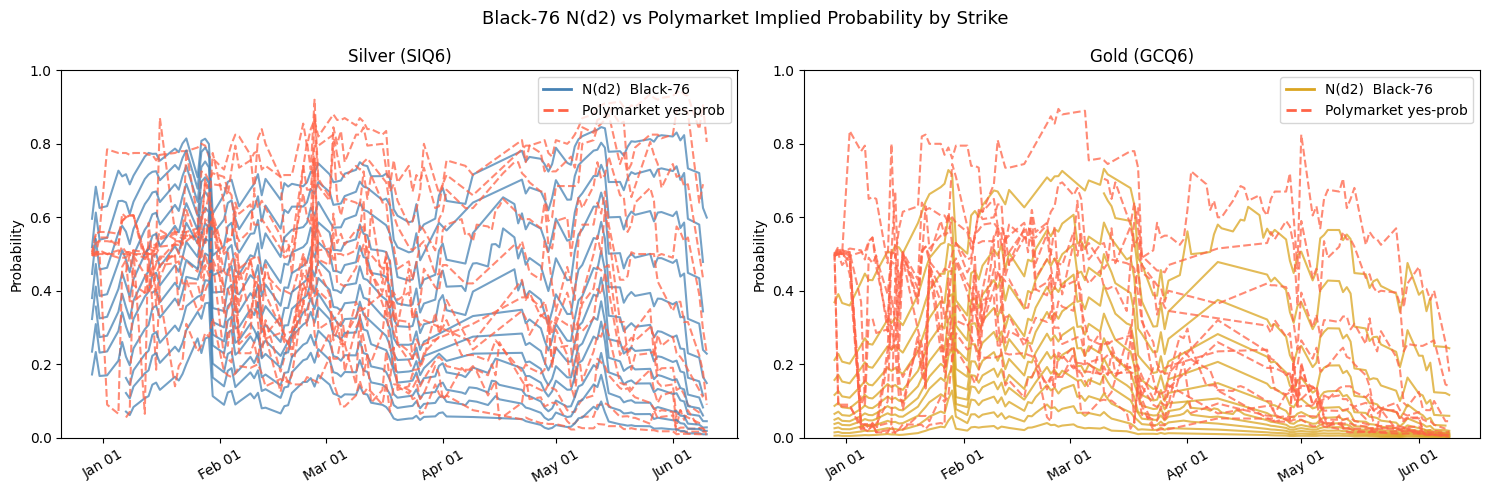

Chart saved → C:\Users\Aidan\Desktop\Research paper Polymarket\nd2_vs_polymarket.png


In [12]:
# ── Plot N(d2) vs Polymarket probability, per underlying ──────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)

configs = [
    ('SI', axes[0], 'steelblue',  'tomato',   'Silver (SIQ6)'),
    ('GC', axes[1], 'goldenrod',  'tomato',   'Gold (GCQ6)'),
]

for label, ax, c_blk, c_pm, title in configs:
    sub = merged[merged['underlying'] == label].dropna(subset=['nd2', 'pm_prob'])
    strikes = sorted(sub['strike'].unique())

    for K in strikes:
        s = sub[sub['strike'] == K].sort_values('date')
        dates = pd.to_datetime(s['date'])
        ax.plot(dates, s['nd2'],     color=c_blk, alpha=0.75, lw=1.5, label=f'N(d2) ${K:.0f}')
        ax.plot(dates, s['pm_prob'], color=c_pm,  alpha=0.75, lw=1.5,
                linestyle='--',     label=f'PM ${K:.0f}')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.tick_params(axis='x', rotation=30)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Probability')
    ax.set_ylim(0, 1)

    # Legend: one entry per series type, not per strike
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0], [0], color=c_blk, lw=2,             label='N(d2)  Black-76'),
        Line2D([0], [0], color=c_pm,  lw=2, ls='--',    label='Polymarket yes-prob'),
    ], loc='upper right')

plt.suptitle('Black-76 N(d2) vs Polymarket Implied Probability by Strike', fontsize=13)
plt.tight_layout()

fig_path = os.path.join(DATA_DIR, 'nd2_vs_polymarket.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved → {fig_path}")


## 13. Moneyness Decomposition Plot

Per-strike mean delta (N(d2) - pm_prob) plotted against moneyness (strike / mean forward price), one panel per asset, points labeled by strike. Tests whether the divergence is systematically larger for ITM vs OTM strikes rather than uniform across the chain.

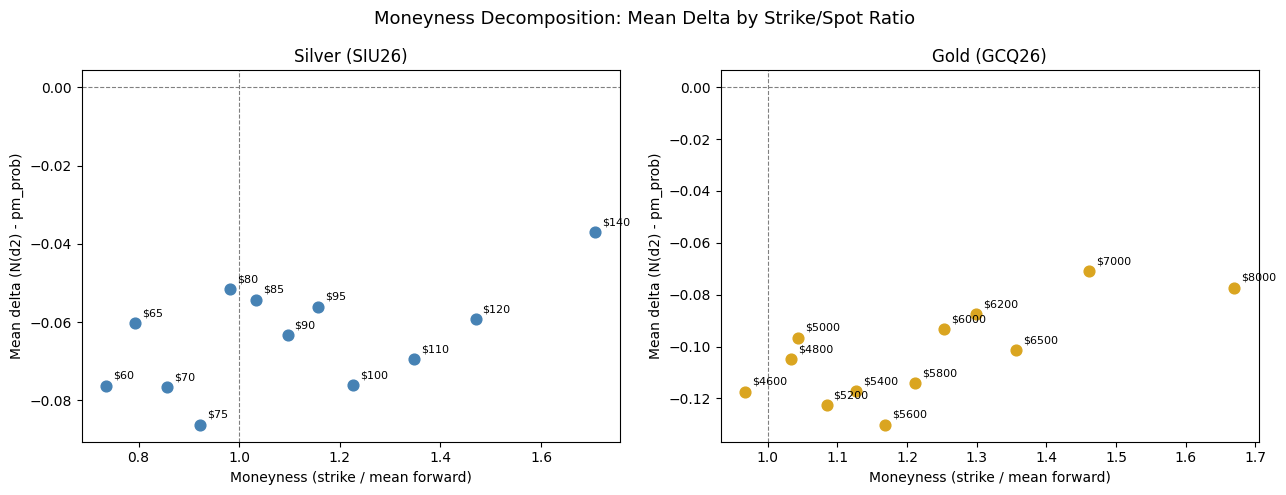

Chart saved -> C:\Users\Aidan\Desktop\Research paper Polymarket\moneyness_decomposition.png


In [13]:
# -- Moneyness decomposition: mean delta vs strike/spot ratio --------------------
# Per-strike mean delta against moneyness (strike / mean forward price), to see
# whether the N(d2) vs Polymarket divergence depends on how far ITM/OTM the
# strike is rather than being uniform across the chain.
if "delta" not in merged.columns:
    merged["delta"] = merged["nd2"] - merged["pm_prob"]

moneyness_rows = []
for und, grp in merged.groupby("underlying"):
    for strike, sub in grp.groupby("strike"):
        moneyness_rows.append({
            "underlying": und,
            "strike":     strike,
            "moneyness":  strike / sub["F"].mean(),
            "mean_delta": sub["delta"].mean(),
            "n":          len(sub),
        })
moneyness_df = pd.DataFrame(moneyness_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
configs = [
    ("SI", axes[0], "steelblue", "Silver (SIU26)"),
    ("GC", axes[1], "goldenrod", "Gold (GCQ26)"),
]

for label, ax, color, title in configs:
    sub = moneyness_df[moneyness_df["underlying"] == label].sort_values("moneyness")
    ax.scatter(sub["moneyness"], sub["mean_delta"], color=color, s=60, zorder=3)
    for _, r in sub.iterrows():
        ax.annotate(
            f"${r['strike']:.0f}",
            (r["moneyness"], r["mean_delta"]),
            textcoords="offset points", xytext=(5, 5), fontsize=8,
        )
    ax.axhline(0, color="gray", lw=0.8, ls="--")
    ax.axvline(1, color="gray", lw=0.8, ls="--")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Moneyness (strike / mean forward)")
    ax.set_ylabel("Mean delta (N(d2) - pm_prob)")

plt.suptitle("Moneyness Decomposition: Mean Delta by Strike/Spot Ratio", fontsize=13)
plt.tight_layout()

fig_path = os.path.join(DATA_DIR, "moneyness_decomposition.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved -> {fig_path}")


## 14. Solver Robustness Check (Brent vs Newton-Raphson)

Re-solves implied vol with a Newton-Raphson root-finder on a random sample of rows from both assets and compares it against the notebook's Brent's-method `iv` (and the resulting N(d2)), reporting the maximum absolute difference. Confirms the implied-vol fit -- and therefore N(d2) and every downstream result -- isn't an artifact of the root-finding method used.

In [14]:
# -- Robustness check: Brent vs Newton-Raphson implied vol -----------------------
# Solves the same rows with Newton-Raphson and compares against the notebook's
# Brent's-method `iv` (already in `merged`), on a fixed-seed random sample from
# both assets, to confirm the result isn't solver-dependent.

def implied_vol_newton(C_mkt, F, K, T, r, sigma0=0.3, tol=1e-7, maxiter=200):
    """Invert Black-76 via Newton-Raphson. Returns NaN on failure."""
    if C_mkt <= 0 or T <= 0 or F <= 0 or K <= 0:
        return np.nan
    lower_bound = np.exp(-r * T) * max(F - K, 0.0)
    if C_mkt <= lower_bound + 1e-9:
        return np.nan
    sigma = sigma0
    for _ in range(maxiter):
        d1, _ = _d1d2(F, K, T, sigma)
        diff  = black76_call(F, K, T, r, sigma) - C_mkt
        if abs(diff) < tol:
            return sigma
        vega = F * np.exp(-r * T) * norm.pdf(d1) * np.sqrt(T)
        if vega < 1e-10:
            return np.nan
        sigma -= diff / vega
        if sigma <= 0 or sigma > 30.0:
            return np.nan
    return np.nan


SAMPLE_N = 50
si_sample = merged[merged["underlying"] == "SI"].dropna(subset=["iv"])
gc_sample = merged[merged["underlying"] == "GC"].dropna(subset=["iv"])
sample_rows = pd.concat([
    si_sample.sample(n=min(SAMPLE_N, len(si_sample)), random_state=42),
    gc_sample.sample(n=min(SAMPLE_N, len(gc_sample)), random_state=42),
], ignore_index=True)

solver_rows = []
for _, row in sample_rows.iterrows():
    F, K, T, C = row["F"], row["strike"], row["T_years"], row["option_price"]
    iv_brent   = row["iv"]
    iv_newton  = implied_vol_newton(C, F, K, T, RISK_FREE)
    nd2_brent  = row["nd2"]
    nd2_newton = black76_nd2(F, K, T, RISK_FREE, iv_newton)
    solver_rows.append({
        "underlying": row["underlying"],
        "strike":     K,
        "date":       row["date"],
        "iv_brent":   iv_brent,
        "iv_newton":  iv_newton,
        "nd2_brent":  nd2_brent,
        "nd2_newton": nd2_newton,
        "diff_iv":    abs(iv_brent - iv_newton),
        "diff_nd2":   abs(nd2_brent - nd2_newton),
    })

solver_df  = pd.DataFrame(solver_rows)
n_failed   = solver_df["iv_newton"].isna().sum()
solver_ok  = solver_df.dropna(subset=["iv_newton"])

max_diff_iv  = solver_ok["diff_iv"].max()
max_diff_nd2 = solver_ok["diff_nd2"].max()

print(f"Sample size: {len(sample_rows)} rows ({sample_rows['underlying'].value_counts().to_dict()})")
print(f"Newton-Raphson failures: {n_failed} (excluded from comparison)")
print(f"Max |IV_brent - IV_newton|        : {max_diff_iv:.2e}")
print(f"Max |N(d2)_brent - N(d2)_newton|  : {max_diff_nd2:.2e}")

TOL = 1e-4
if max_diff_iv < TOL and max_diff_nd2 < TOL:
    print(f"\nDifferences are negligible (< {TOL:.0e}): Brent's method and Newton-Raphson "
          f"agree, so the implied-vol fit -- and therefore N(d2) and every downstream "
          f"result -- is NOT solver-dependent.")
else:
    print(f"\n[warn] Differences exceed {TOL:.0e} -- results may be solver-dependent.")

display(
    solver_ok.sort_values("diff_nd2", ascending=False)
    .head(10)
    [["underlying", "strike", "date", "iv_brent", "iv_newton",
      "nd2_brent", "nd2_newton", "diff_iv", "diff_nd2"]]
    .style
    .format({
        "iv_brent":   "{:.6f}",
        "iv_newton":  "{:.6f}",
        "nd2_brent":  "{:.6f}",
        "nd2_newton": "{:.6f}",
        "diff_iv":    "{:.2e}",
        "diff_nd2":   "{:.2e}",
    })
    .set_caption("Top 10 largest Brent vs Newton-Raphson differences (sample)")
)


Sample size: 100 rows ({'SI': 50, 'GC': 50})
Newton-Raphson failures: 6 (excluded from comparison)
Max |IV_brent - IV_newton|        : 2.49e-08
Max |N(d2)_brent - N(d2)_newton|  : 1.37e-08

Differences are negligible (< 1e-04): Brent's method and Newton-Raphson agree, so the implied-vol fit -- and therefore N(d2) and every downstream result -- is NOT solver-dependent.


,underlying,strike,date,iv_brent,iv_newton,nd2_brent,nd2_newton,diff_iv,diff_nd2
84,GC,5200.000000,2026-05-21,0.243984,0.243984,0.090725,0.090725,1.66e-08,1.37e-08
59,GC,7000.000000,2026-01-23,0.311271,0.311271,0.057498,0.057498,2.49e-08,1.25e-08
79,GC,5000.000000,2026-01-13,0.232477,0.232477,0.312245,0.312245,2.49e-08,1.21e-08
87,GC,6500.000000,2026-01-27,0.293153,0.293153,0.111272,0.111272,1.64e-08,1.07e-08
33,SI,70.000000,2026-05-21,0.405180,0.405180,0.615537,0.615537,1.88e-08,9.46e-09
52,GC,5000.000000,2026-05-21,0.235427,0.235427,0.159833,0.159833,1.01e-08,9.32e-09
36,SI,75.000000,2026-05-13,0.508845,0.508845,0.667275,0.667275,1.73e-08,9.18e-09
46,SI,140.000000,2026-03-09,0.716896,0.716896,0.117262,0.117262,2.03e-08,3.65e-09
63,GC,5600.000000,2026-03-11,0.285377,0.285377,0.312374,0.312374,8.99e-09,3.49e-09
31,SI,110.000000,2026-03-24,0.638236,0.638236,0.114738,0.114738,1.42e-08,3.21e-09


## 15. Extreme-Strike Robustness Check

Re-runs the one-sample t-test on delta after dropping the most extreme OTM strikes per asset (SI: $120/$140, GC: $7,000/$8,000), and compares mean delta and significance against the all-strikes baseline. Confirms the systematic divergence isn't driven solely by the thinnest, most illiquid strikes in the chain.

In [15]:
# -- Robustness check: excluding most extreme OTM strikes ------------------------
# Re-runs the one-sample t-test on delta after dropping the most extreme OTM
# strikes per asset (reuses _ttest_row from the T-Test Analysis section above),
# to confirm the divergence isn't driven solely by the thinnest, most illiquid
# strikes in the chain.
if "delta" not in merged.columns:
    merged["delta"] = merged["nd2"] - merged["pm_prob"]

EXCLUDE_STRIKES = {"SI": [120.0, 140.0], "GC": [7000.0, 8000.0]}

extreme_rows = []
for und, grp in merged.groupby("underlying"):
    excluded = EXCLUDE_STRIKES.get(und, [])
    excl_grp = grp[~grp["strike"].isin(excluded)]

    row_all = _ttest_row(und, "all_strikes", grp["delta"])
    row_all["excluded_strikes"] = ""
    row_all["n_excluded"] = 0
    extreme_rows.append(row_all)

    row_excl = _ttest_row(und, "excl_extreme_otm", excl_grp["delta"])
    row_excl["excluded_strikes"] = ", ".join(f"${k:.0f}" for k in excluded)
    row_excl["n_excluded"] = len(grp) - len(excl_grp)
    extreme_rows.append(row_excl)

extreme_df = (
    pd.DataFrame(extreme_rows)
    .rename(columns={"strike": "subset"})
    [["underlying", "subset", "excluded_strikes", "n_excluded", "n",
      "mean_delta", "std_delta", "t_stat", "p_value", "ci_lo_95", "ci_hi_95", "reject_H0"]]
)

extreme_path = os.path.join(DATA_DIR, "extreme_strike_robustness.csv")
extreme_df.to_csv(extreme_path, index=False)
print(f"Saved -> {extreme_path}\n")

for und in EXCLUDE_STRIKES:
    base = extreme_df[(extreme_df["underlying"] == und) & (extreme_df["subset"] == "all_strikes")].iloc[0]
    excl = extreme_df[(extreme_df["underlying"] == und) & (extreme_df["subset"] == "excl_extreme_otm")].iloc[0]
    delta_change = excl["mean_delta"] - base["mean_delta"]
    pct_change   = delta_change / base["mean_delta"] * 100 if base["mean_delta"] != 0 else float("nan")
    print(f"{und}: excluding {excl['excluded_strikes']} ({excl['n_excluded']} rows)")
    print(f"  mean delta {base['mean_delta']:.5f} -> {excl['mean_delta']:.5f} "
          f"(Δ={delta_change:+.5f}, {pct_change:+.1f}%)")
    print(f"  p-value    {base['p_value']:.2e} -> {excl['p_value']:.2e}; "
          f"reject_H0 {base['reject_H0']} -> {excl['reject_H0']}")
    if bool(base["reject_H0"]) == bool(excl["reject_H0"]) and abs(pct_change) < 20:
        print(f"  -> robust: excluding the most extreme OTM strikes does not change the conclusion.\n")
    else:
        print(f"  -> [warn] excluding the most extreme OTM strikes meaningfully changes the result.\n")

display(
    extreme_df
    .style
    .format({
        "mean_delta": "{:.5f}",
        "std_delta":  "{:.5f}",
        "t_stat":     "{:.3f}",
        "p_value":    "{:.4f}",
        "ci_lo_95":   "{:.5f}",
        "ci_hi_95":   "{:.5f}",
    })
    .set_caption(
        "Extreme-strike robustness: t-test on delta, all strikes vs excluding most extreme OTM"
    )
)


Saved -> C:\Users\Aidan\Desktop\Research paper Polymarket\extreme_strike_robustness.csv

SI: excluding $120, $140 (199 rows)
  mean delta -0.06442 -> -0.06759 (Δ=-0.00317, +4.9%)
  p-value    3.81e-107 -> 9.66e-98; reject_H0 True -> True
  -> robust: excluding the most extreme OTM strikes does not change the conclusion.

GC: excluding $7000, $8000 (192 rows)
  mean delta -0.10265 -> -0.10854 (Δ=-0.00589, +5.7%)
  p-value    2.12e-150 -> 3.00e-130; reject_H0 True -> True
  -> robust: excluding the most extreme OTM strikes does not change the conclusion.



,underlying,subset,excluded_strikes,n_excluded,n,mean_delta,std_delta,t_stat,p_value,ci_lo_95,ci_hi_95,reject_H0
0,GC,all_strikes,,0,1121,-0.10265,0.11209,-30.662,0.0000,-0.10922,-0.09608,True
1,GC,excl_extreme_otm,"$7000, $8000",192,929,-0.10854,0.11522,-28.712,0.0000,-0.11596,-0.10112,True
2,SI,all_strikes,,0,1196,-0.06442,0.09125,-24.416,0.0000,-0.06960,-0.05925,True
3,SI,excl_extreme_otm,"$120, $140",199,997,-0.06759,0.09068,-23.535,0.0000,-0.07323,-0.06195,True


## 16. Permutation Null Benchmark (pooled relabeling)

For each asset, pools all `nd2` and `pm_prob` values together and randomly re-splits them into two groups of the original sizes (i.e. reassigns the "is this an N(d2) value or a pm_prob value" label at random), recomputing the resulting group-mean difference, repeated 1,000 times. This is the standard permutation/randomization test for a difference in means and represents the null "N(d2) and Polymarket pricing are exchangeable -- no systematic relationship." Compares the observed mean delta to this null and reports the empirical p-value (fraction of null differences at least as extreme as observed).

Note: two more literal readings of "shuffle and recompute" were ruled out as mathematically degenerate. (1) Reordering `pm_prob` alone (a permutation) never changes its mean, so `mean(nd2 - shuffled_pm_prob)` is guaranteed to equal the observed mean delta exactly. (2) Bootstrap-resampling `pm_prob` alone with replacement (holding `nd2` fixed) centers the null exactly on the observed value by construction, forcing an empirical p-value near 0.5 regardless of the true effect. Pooling both sides and randomly relabeling avoids both degeneracies and is the textbook construction for this test.

In [16]:
# -- Permutation null benchmark: pooled nd2/pm_prob relabeling -------------------
# Pools all nd2 and pm_prob values for each asset and randomly re-splits them into
# two groups of the original sizes, recomputing the group-mean difference, 1000
# times. This is the standard permutation/randomization test for a difference in
# means and represents the null "N(d2) and Polymarket pricing are exchangeable --
# no systematic relationship." Two more literal readings were ruled out as
# degenerate: (1) shuffling pm_prob alone never changes its mean, so mean(nd2 -
# shuffled_pm) is guaranteed to equal the observed value exactly; (2) bootstrap-
# resampling pm_prob alone (with replacement, holding nd2 fixed) centers the null
# exactly on the observed value, forcing p ~= 0.5 regardless of the true effect.

N_PERM = 1000
rng = np.random.default_rng(42)

null_rows = []
for und, grp in merged.dropna(subset=["nd2", "pm_prob"]).groupby("underlying"):
    nd2_vals = grp["nd2"].values
    pm_vals  = grp["pm_prob"].values
    n        = len(grp)
    observed_mean = nd2_vals.mean() - pm_vals.mean()

    pooled = np.concatenate([nd2_vals, pm_vals])
    null_means = np.empty(N_PERM)
    for i in range(N_PERM):
        shuffled = rng.permutation(pooled)
        null_means[i] = shuffled[:n].mean() - shuffled[n:].mean()

    ci_lo, ci_hi = np.percentile(null_means, [2.5, 97.5])
    n_extreme = int((np.abs(null_means) >= abs(observed_mean)).sum())
    p_emp = n_extreme / N_PERM

    null_rows.append({
        "underlying":          und,
        "n_obs":               n,
        "n_permutations":      N_PERM,
        "observed_mean_delta": observed_mean,
        "null_mean":           null_means.mean(),
        "null_std":            null_means.std(ddof=1),
        "null_ci_lo_95":       ci_lo,
        "null_ci_hi_95":       ci_hi,
        "n_extreme":           n_extreme,
        "empirical_p_value":   p_emp,
    })

null_df = pd.DataFrame(null_rows)

null_path = os.path.join(DATA_DIR, "null_benchmark.csv")
null_df.to_csv(null_path, index=False)
print(f"Saved -> {null_path}\n")

for _, r in null_df.iterrows():
    outside_ci = not (r["null_ci_lo_95"] <= r["observed_mean_delta"] <= r["null_ci_hi_95"])
    p_str = (f"{r['empirical_p_value']:.4f}" if r["empirical_p_value"] > 0
              else f"< {1 / N_PERM:.4f} (0/{N_PERM} permutations as extreme)")
    print(f"{r['underlying']}: observed mean delta = {r['observed_mean_delta']:.5f}  |  "
          f"null mean = {r['null_mean']:.5f} (std={r['null_std']:.5f}), "
          f"95% range [{r['null_ci_lo_95']:.5f}, {r['null_ci_hi_95']:.5f}]")
    print(f"  empirical p-value = {p_str} "
          f"({'observed falls OUTSIDE' if outside_ci else 'observed falls INSIDE'} the null 95% range)")
    if r["empirical_p_value"] < 0.05:
        print(f"  -> the observed divergence is highly unlikely under the null of no systematic relationship.\n")
    else:
        print(f"  -> [warn] the observed divergence is consistent with the null -- not distinguishable from random pairing.\n")

display(
    null_df
    .style
    .format({
        "observed_mean_delta": "{:.5f}",
        "null_mean":           "{:.5f}",
        "null_std":            "{:.5f}",
        "null_ci_lo_95":       "{:.5f}",
        "null_ci_hi_95":       "{:.5f}",
        "empirical_p_value":   "{:.4f}",
    })
    .set_caption(f"Permutation null benchmark: observed mean delta vs {N_PERM} pooled-relabeling nulls")
)


Saved -> C:\Users\Aidan\Desktop\Research paper Polymarket\null_benchmark.csv

GC: observed mean delta = -0.10265  |  null mean = -0.00007 (std=0.00885), 95% range [-0.01814, 0.01764]
  empirical p-value = < 0.0010 (0/1000 permutations as extreme) (observed falls OUTSIDE the null 95% range)
  -> the observed divergence is highly unlikely under the null of no systematic relationship.

SI: observed mean delta = -0.06442  |  null mean = -0.00032 (std=0.00943), 95% range [-0.01827, 0.01830]
  empirical p-value = < 0.0010 (0/1000 permutations as extreme) (observed falls OUTSIDE the null 95% range)
  -> the observed divergence is highly unlikely under the null of no systematic relationship.



,underlying,n_obs,n_permutations,observed_mean_delta,null_mean,null_std,null_ci_lo_95,null_ci_hi_95,n_extreme,empirical_p_value
0,GC,1121,1000,-0.10265,-0.00007,0.00885,-0.01814,0.01764,0,0.0000
1,SI,1196,1000,-0.06442,-0.00032,0.00943,-0.01827,0.01830,0,0.0000


## 17. Risk-Free Rate Sensitivity Check

Re-solves implied vol and recomputes N(d2) for every row in the merged dataset using `RISK_FREE = 0.037` (3.7%) instead of the baseline `0.045` (4.5%). Compares mean delta and one-sample t-test significance per asset (and per strike) to assess how sensitive the core result is to the assumed risk-free rate. Saves the full comparison to `risk_free_sensitivity.csv`.

In [17]:
# -- Risk-free rate sensitivity: r=0.037 vs baseline r=0.045 -------------------
# Re-solves implied vol and recomputes N(d2) for every merged row using
# RISK_FREE_ALT=0.037, then compares mean delta and t-test significance against
# the baseline (r=0.045) per asset and per (asset, strike).
from scipy import stats as scipy_stats

RISK_FREE_ALT = 0.037   # 3.7% alternative

# Re-compute IV and N(d2) row-by-row with the alternative rate
iv_alt_vals  = []
nd2_alt_vals = []
for _, row in merged.iterrows():
    iv_a  = implied_vol(row['option_price'], row['F'], row['strike'],
                        row['T_years'], RISK_FREE_ALT)
    nd2_a = black76_nd2(row['F'], row['strike'], row['T_years'], RISK_FREE_ALT, iv_a)
    iv_alt_vals.append(iv_a)
    nd2_alt_vals.append(nd2_a)

merged['iv_alt']    = iv_alt_vals
merged['nd2_alt']   = nd2_alt_vals
merged['delta_alt'] = merged['nd2_alt'] - merged['pm_prob']   # delta under alt rate


def _sens_row(und, strike_label, d_base, d_alt):
    d_base = d_base.dropna().values
    d_alt  = d_alt.dropna().values
    t_b, p_b = scipy_stats.ttest_1samp(d_base, popmean=0)
    t_a, p_a = scipy_stats.ttest_1samp(d_alt,  popmean=0)
    m_b, m_a = d_base.mean(), d_alt.mean()
    pct = (m_a - m_b) / abs(m_b) * 100 if m_b != 0 else float('nan')
    return {
        'underlying':            und,
        'strike':                strike_label,
        'n':                     len(d_base),
        'mean_delta_r0045':      m_b,
        'mean_delta_r0037':      m_a,
        'pct_change_mean_delta': pct,
        't_stat_r0045':          t_b,
        'p_value_r0045':         p_b,
        'reject_H0_r0045':       bool(p_b < 0.05),
        't_stat_r0037':          t_a,
        'p_value_r0037':         p_a,
        'reject_H0_r0037':       bool(p_a < 0.05),
        'significance_changes':  bool(p_b < 0.05) != bool(p_a < 0.05),
    }


# Overall per-asset
overall_sens = [
    _sens_row(und, 'ALL', grp['delta'], grp['delta_alt'])
    for und, grp in merged.groupby('underlying')
]

# Per (asset, strike)
strike_sens = [
    _sens_row(und, str(k), grp['delta'], grp['delta_alt'])
    for (und, k), grp in merged.groupby(['underlying', 'strike'])
]

sens_df = pd.concat(
    [pd.DataFrame(overall_sens).sort_values('underlying'),
     pd.DataFrame(strike_sens).sort_values(['underlying', 'strike'])],
    ignore_index=True,
)

sens_path = os.path.join(DATA_DIR, 'risk_free_sensitivity.csv')
sens_df.to_csv(sens_path, index=False)
print(f"Saved -> {sens_path}\n")

# ── Summary printout ────────────────────────────────────────────────────────────
print(f"Risk-free rate sensitivity: r = {RISK_FREE:.3f} (baseline) vs r = {RISK_FREE_ALT:.3f} (alt)\n")
_r_base_label = f'mean_δ r={RISK_FREE*100:.1f}%'
_r_alt_label  = f'mean_δ r={RISK_FREE_ALT*100:.1f}%'
_p_base_label = f'p ({RISK_FREE*100:.1f}%)'
_p_alt_label  = f'p ({RISK_FREE_ALT*100:.1f}%)'
print(f"{'Asset':<5}  {_r_base_label:>14}  {_r_alt_label:>14}  "
      f"{'Δ%':>8}  {_p_base_label:>12}  {_p_alt_label:>12}  {'sig chg?':>9}")
print("─" * 88)
for _, r in sens_df[sens_df['strike'] == 'ALL'].iterrows():
    print(f"{r['underlying']:<5}  {r['mean_delta_r0045']:>14.5f}  {r['mean_delta_r0037']:>14.5f}  "
          f"{r['pct_change_mean_delta']:>+8.2f}%  {r['p_value_r0045']:>12.2e}  "
          f"{r['p_value_r0037']:>12.2e}  {'YES' if r['significance_changes'] else 'no':>9}")

display(
    sens_df[sens_df['strike'] == 'ALL'][[
        'underlying', 'n',
        'mean_delta_r0045', 'mean_delta_r0037', 'pct_change_mean_delta',
        'p_value_r0045', 'reject_H0_r0045',
        'p_value_r0037', 'reject_H0_r0037',
        'significance_changes',
    ]]
    .style
    .format({
        'mean_delta_r0045':      '{:.5f}',
        'mean_delta_r0037':      '{:.5f}',
        'pct_change_mean_delta': '{:+.2f}%',
        'p_value_r0045':         '{:.2e}',
        'p_value_r0037':         '{:.2e}',
    })
    .set_caption(
        f'Risk-free sensitivity (per asset): RISK_FREE={RISK_FREE:.3f} vs {RISK_FREE_ALT:.3f}  |  '
        'H₀: mean(N(d2) − pm_prob) = 0'
    )
)

print("\nPer-strike breakdown:")
display(
    sens_df[sens_df['strike'] != 'ALL'][[
        'underlying', 'strike', 'n',
        'mean_delta_r0045', 'mean_delta_r0037', 'pct_change_mean_delta',
        'p_value_r0045', 'reject_H0_r0045',
        'p_value_r0037', 'reject_H0_r0037',
        'significance_changes',
    ]]
    .style
    .format({
        'mean_delta_r0045':      '{:.5f}',
        'mean_delta_r0037':      '{:.5f}',
        'pct_change_mean_delta': '{:+.2f}%',
        'p_value_r0045':         '{:.2e}',
        'p_value_r0037':         '{:.2e}',
    })
    .set_caption(
        f'Risk-free sensitivity (per strike): RISK_FREE={RISK_FREE:.3f} vs {RISK_FREE_ALT:.3f}'
    )
)

Saved -> C:\Users\Aidan\Desktop\Research paper Polymarket\risk_free_sensitivity.csv

Risk-free rate sensitivity: r = 0.045 (baseline) vs r = 0.037 (alt)

Asset   mean_δ r=4.5%   mean_δ r=3.7%        Δ%      p (4.5%)      p (3.7%)   sig chg?
────────────────────────────────────────────────────────────────────────────────────────
GC           -0.10265        -0.10269     -0.04%     2.12e-150     2.29e-150         no
SI           -0.06442        -0.06342     +1.55%     3.81e-107     1.04e-103         no


,underlying,n,mean_delta_r0045,mean_delta_r0037,pct_change_mean_delta,p_value_r0045,reject_H0_r0045,p_value_r0037,reject_H0_r0037,significance_changes
0,GC,1121,-0.10265,-0.10269,-0.04%,2.12e-150,True,2.29e-150,True,False
1,SI,1196,-0.06442,-0.06342,+1.55%,3.81e-107,True,1.04e-103,True,False



Per-strike breakdown:


,underlying,strike,n,mean_delta_r0045,mean_delta_r0037,pct_change_mean_delta,p_value_r0045,reject_H0_r0045,p_value_r0037,reject_H0_r0037,significance_changes
2,GC,4600.0,101,-0.11735,-0.11674,+0.52%,1.58e-22,True,2.34e-22,True,False
3,GC,4800.0,47,-0.10498,-0.10495,+0.02%,8.22e-14,True,8.82e-14,True,False
4,GC,5000.0,96,-0.09651,-0.09647,+0.04%,3.65e-16,True,4.02e-16,True,False
5,GC,5200.0,95,-0.12263,-0.12273,-0.08%,1.97e-17,True,1.98e-17,True,False
6,GC,5400.0,97,-0.11716,-0.11732,-0.14%,2.97e-17,True,2.85e-17,True,False
7,GC,5600.0,97,-0.13018,-0.13035,-0.14%,2.73e-14,True,2.62e-14,True,False
8,GC,5800.0,94,-0.11414,-0.11431,-0.15%,4.16e-13,True,3.97e-13,True,False
9,GC,6000.0,109,-0.09337,-0.09352,-0.16%,3.98e-13,True,3.75e-13,True,False
10,GC,6200.0,96,-0.08751,-0.08764,-0.15%,2.98e-11,True,2.85e-11,True,False
11,GC,6500.0,97,-0.10139,-0.10150,-0.11%,1.66e-12,True,1.61e-12,True,False


## 18. HAC (Newey-West) Robustness Check

The plain t-test in Section 7 assumes i.i.d. observations. Because `delta` is observed daily across multiple correlated strikes, the series exhibits both time-series autocorrelation (option prices carry over day-to-day) and cross-sectional correlation (all strikes on the same date share the same underlying price). Newey-West HAC-robust standard errors correct for both.

For each asset, OLS regresses `delta` on a constant — the intercept equals `mean(delta)`, so the intercept t-test is equivalent to H₀: mean delta = 0. We try three lag windows (5, 10, 20 days) to check sensitivity of the inference to lag choice. Results are saved to `hac_robustness.csv`.

In [18]:
# -- HAC (Newey-West) robustness: OLS delta ~ 1 with HAC SEs ---------------------
# OLS on a constant: intercept = mean(delta), so the intercept t-stat tests
# H0: mean(delta) = 0, same null as the plain t-test in Section 7.
# Newey-West SEs with maxlags in {5, 10, 20} correct for autocorrelation and
# heteroskedasticity in the pooled panel without assuming any specific structure.
import statsmodels.api as sm
from scipy import stats as scipy_stats

if "delta" not in merged.columns:
    merged["delta"] = merged["nd2"] - merged["pm_prob"]

HAC_LAGS = [5, 10, 20]

hac_rows = []
for und, grp in merged.dropna(subset=["delta"]).groupby("underlying"):
    delta = grp.sort_values("date")["delta"].values
    n     = len(delta)

    # Plain t-test baseline (same as Section 7 "ALL" row)
    t_plain, p_plain = scipy_stats.ttest_1samp(delta, popmean=0)

    for lag in HAC_LAGS:
        res = sm.OLS(delta, np.ones(n)).fit(
            cov_type="HAC", cov_kwds={"maxlags": lag}, use_t=True
        )
        t_hac = float(res.tvalues[0])
        p_hac = float(res.pvalues[0])
        hac_rows.append({
            "underlying":      und,
            "n":               n,
            "hac_maxlags":     lag,
            "mean_delta":      float(res.params[0]),
            "plain_t_stat":    t_plain,
            "plain_p_value":   p_plain,
            "hac_t_stat":      t_hac,
            "hac_p_value":     p_hac,
            "reject_H0_plain": bool(p_plain < 0.05),
            "reject_H0_hac":   bool(p_hac   < 0.05),
        })

hac_df = pd.DataFrame(hac_rows)

hac_path = os.path.join(DATA_DIR, "hac_robustness.csv")
hac_df.to_csv(hac_path, index=False)
print(f"Saved -> {hac_path}\n")

# ── Text summary ────────────────────────────────────────────────────────────────
hdr = (f"{'Asset':<5}  {'lags':>5}  {'n':>5}  {'mean_delta':>11}"
       f"  {'t (plain)':>10}  {'p (plain)':>11}"
       f"  {'t (HAC)':>9}  {'p (HAC)':>11}"
       f"  {'plain':>6}  {'HAC':>6}")
print(hdr)
print("─" * len(hdr))
for _, r in hac_df.iterrows():
    print(f"{r['underlying']:<5}  {int(r['hac_maxlags']):>5}  {int(r['n']):>5}  "
          f"{r['mean_delta']:>11.5f}"
          f"  {r['plain_t_stat']:>10.3f}  {r['plain_p_value']:>11.2e}"
          f"  {r['hac_t_stat']:>9.3f}  {r['hac_p_value']:>11.2e}"
          f"  {'rej' if r['reject_H0_plain'] else 'fail':>6}"
          f"  {'rej' if r['reject_H0_hac'] else 'fail':>6}")

display(
    hac_df
    .style
    .format({
        "mean_delta":    "{:.5f}",
        "plain_t_stat":  "{:.3f}",
        "plain_p_value": "{:.3e}",
        "hac_t_stat":    "{:.3f}",
        "hac_p_value":   "{:.3e}",
    })
    .set_caption(
        "HAC (Newey-West) robustness: OLS delta ~ 1, plain t-test vs HAC SEs  |  "
        "H₀: mean(N(d2) − pm_prob) = 0  |  lags 5 / 10 / 20"
    )
)

Saved -> C:\Users\Aidan\Desktop\Research paper Polymarket\hac_robustness.csv

Asset   lags      n   mean_delta   t (plain)    p (plain)    t (HAC)      p (HAC)   plain     HAC
─────────────────────────────────────────────────────────────────────────────────────────────────
GC         5   1121     -0.10265     -30.662    2.12e-150    -16.753     2.20e-56     rej     rej
GC        10   1121     -0.10265     -30.662    2.12e-150    -13.072     1.92e-36     rej     rej
GC        20   1121     -0.10265     -30.662    2.12e-150    -10.027     1.01e-22     rej     rej
SI         5   1196     -0.06442     -24.416    3.81e-107    -17.378     1.76e-60     rej     rej
SI        10   1196     -0.06442     -24.416    3.81e-107    -14.619     1.20e-44     rej     rej
SI        20   1196     -0.06442     -24.416    3.81e-107    -12.416     2.22e-33     rej     rej


,underlying,n,hac_maxlags,mean_delta,plain_t_stat,plain_p_value,hac_t_stat,hac_p_value,reject_H0_plain,reject_H0_hac
0,GC,1121,5,-0.10265,-30.662,2.119e-150,-16.753,2.195e-56,True,True
1,GC,1121,10,-0.10265,-30.662,2.119e-150,-13.072,1.917e-36,True,True
2,GC,1121,20,-0.10265,-30.662,2.119e-150,-10.027,1.015e-22,True,True
3,SI,1196,5,-0.06442,-24.416,3.808e-107,-17.378,1.759e-60,True,True
4,SI,1196,10,-0.06442,-24.416,3.808e-107,-14.619,1.196e-44,True,True
5,SI,1196,20,-0.06442,-24.416,3.808e-107,-12.416,2.220e-33,True,True


## 19. Time-Series Diagnostics (AR(1) Persistence & ADF Stationarity)

Both tests use the **date-level mean delta** (mean of N(d2) - pm_prob across all strikes for a given asset on a given day), so N = number of unique trading dates rather than total rows. This removes the cross-strike dimension and treats the series as a clean daily time series.

**AR(1) persistence:** Regresses delta_t on delta_{t-1} (one trading-day lag). The AR(1) coefficient rho measures how much of yesterday's mispricing carries into today. The implied half-life = ln(0.5) / ln(rho) gives the number of days for the gap to close halfway, assuming mean reversion (0 < rho < 1).

**ADF stationarity test:** statsmodels.tsa.stattools.adfuller with regression='c' (demeaned) and AIC-selected lag order. H0 = unit root (non-stationary). Rejection at 5% means the delta series is stationary -- the N(d2)/Polymarket gap does not drift without bound.

In [19]:
# -- Time-series diagnostics: AR(1) persistence and ADF stationarity ----------
# Uses the date-level mean delta (mean across strikes per date per asset),
# so N = trading dates, not total rows. Removes cross-strike correlation from
# the time-series tests.
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

if "delta" not in merged.columns:
    merged["delta"] = merged["nd2"] - merged["pm_prob"]

# ---- Date-level mean delta per asset -----------------------------------------
date_delta = (
    merged.groupby(["underlying", "date"])["delta"]
    .mean()
    .reset_index()
    .sort_values(["underlying", "date"])
)

diag_rows = []

for und, grp in date_delta.groupby("underlying"):
    y = grp["delta"].values
    n = len(y)

    # ---- AR(1): delta_t = alpha + rho * delta_{t-1} + eps --------------------
    y_t   = y[1:]    # delta_t
    y_lag = y[:-1]   # delta_{t-1}
    ar1_res = sm.OLS(y_t, sm.add_constant(y_lag)).fit()
    rho    = float(ar1_res.params[1])
    rho_se = float(ar1_res.bse[1])
    # half-life meaningful only when 0 < rho < 1 (stationary mean-reverting)
    if 0 < abs(rho) < 1:
        half_life = np.log(0.5) / np.log(abs(rho))
    else:
        half_life = float("nan")

    # ---- ADF stationarity test -----------------------------------------------
    adf_stat, adf_pval, adf_lags_used, adf_nobs, adf_crit, _ = adfuller(
        y, autolag="AIC", regression="c"
    )
    stationary_5pct = bool(adf_pval < 0.05)

    diag_rows.append({
        "underlying":      und,
        "n_dates":         n,
        "ar1_coeff":       rho,
        "ar1_se":          rho_se,
        "half_life_days":  half_life,
        "adf_stat":        adf_stat,
        "adf_pval":        adf_pval,
        "adf_lags_used":   adf_lags_used,
        "adf_crit_1pct":   adf_crit["1%"],
        "adf_crit_5pct":   adf_crit["5%"],
        "adf_crit_10pct":  adf_crit["10%"],
        "stationary_5pct": stationary_5pct,
    })

    if not np.isnan(half_life):
        hl_str = f"{half_life:.1f} trading days"
    else:
        hl_str = "n/a (|rho| >= 1)"
    print(f"-- {und}  n_dates={n} -------------------------------------------")
    print(f"  AR(1) rho = {rho:.5f}  (SE={rho_se:.5f})")
    print(f"  Half-life = {hl_str}")
    print(f"  ADF stat  = {adf_stat:.4f}   p = {adf_pval:.4f}   lags used = {adf_lags_used}")
    print(f"  Critical values: 1%={adf_crit['1%']:.3f}  5%={adf_crit['5%']:.3f}  "
          f"10%={adf_crit['10%']:.3f}")
    print(f"  -> {'STATIONARY' if stationary_5pct else 'NON-STATIONARY'} at 5% level\n")

diag_df = pd.DataFrame(diag_rows)

diag_path = os.path.join(DATA_DIR, "timeseries_diagnostics.csv")
diag_df.to_csv(diag_path, index=False)
print(f"Saved -> {diag_path}")

display(
    diag_df[[
        "underlying", "n_dates",
        "ar1_coeff", "ar1_se", "half_life_days",
        "adf_stat", "adf_pval", "adf_lags_used",
        "adf_crit_5pct", "stationary_5pct",
    ]]
    .style
    .format({
        "ar1_coeff":      "{:.5f}",
        "ar1_se":         "{:.5f}",
        "half_life_days": "{:.1f}",
        "adf_stat":       "{:.4f}",
        "adf_pval":       "{:.4f}",
        "adf_crit_5pct":  "{:.3f}",
    })
    .set_caption(
        "Time-series diagnostics on date-level mean delta (per asset):  "
        "AR(1) persistence and ADF stationarity test"
    )
)

-- GC  n_dates=112 -------------------------------------------
  AR(1) rho = 0.73493  (SE=0.05670)
  Half-life = 2.3 trading days
  ADF stat  = -3.9026   p = 0.0020   lags used = 1
  Critical values: 1%=-3.491  5%=-2.888  10%=-2.581
  -> STATIONARY at 5% level

-- SI  n_dates=113 -------------------------------------------
  AR(1) rho = 0.30788  (SE=0.09072)
  Half-life = 0.6 trading days
  ADF stat  = -7.6289   p = 0.0000   lags used = 0
  Critical values: 1%=-3.490  5%=-2.888  10%=-2.581
  -> STATIONARY at 5% level

Saved -> C:\Users\Aidan\Desktop\Research paper Polymarket\timeseries_diagnostics.csv


,underlying,n_dates,ar1_coeff,ar1_se,half_life_days,adf_stat,adf_pval,adf_lags_used,adf_crit_5pct,stationary_5pct
0,GC,112,0.73493,0.05670,2.3,-3.9026,0.0020,1,-2.888,True
1,SI,113,0.30788,0.09072,0.6,-7.6289,0.0000,0,-2.888,True


## 20. Realized Risk Premium Estimate
Stitch the GCM26 (pre-roll) and GCQ26 (post-roll) price series and the SIU26 series,
compute daily log excess returns, and estimate how much the realized risk premium
over the sample period would shift the lognormal probability of finishing above the
mean strike relative to the risk-neutral N(d2).

In [20]:
# ── Section 20: Realized Risk Premium Estimate ──────────────────────────────
# Uses stitched GC (GCM26 pre-roll / GCQ26 post-roll) and SIU26 price series
# already loaded in Section 3.

K_GC_REF      = 5_400.0   # reference strike for Gold  (mean of strike ladder)
K_SI_REF      =    85.0   # reference strike for Silver (mean of strike ladder)
MEAN_DELTA_GC =   -0.103  # observed mean delta = N(d2) - pm_prob  (Section 7)
MEAN_DELTA_SI =   -0.064

# 1. Sort stitched price series ascending by date
gc_ts = gc_spot_adj.sort_values("Time").reset_index(drop=True).copy()
si_ts = si_spot.sort_values("Time").reset_index(drop=True).copy()

# 2. Daily log returns
gc_ts["log_ret"] = np.log(gc_ts["F"] / gc_ts["F"].shift(1))
si_ts["log_ret"] = np.log(si_ts["F"] / si_ts["F"].shift(1))

# 3. Daily excess returns  (subtract daily risk-free rate)
daily_rf = RISK_FREE / 252
gc_ts["xs_ret"] = gc_ts["log_ret"] - daily_rf
si_ts["xs_ret"] = si_ts["log_ret"] - daily_rf

gc_xs = gc_ts["xs_ret"].dropna()
si_xs = si_ts["xs_ret"].dropna()

# 4. Summary statistics
def _rp_stats(xs, log_ret_series, label):
    n        = len(xs)
    mean_d   = xs.mean()
    std_d    = xs.std(ddof=1)
    mean_ann = mean_d * 252
    std_ann  = std_d * np.sqrt(252)
    sharpe   = mean_ann / std_ann if std_ann > 0 else np.nan
    cum_log  = log_ret_series.dropna().sum()   # ln(F_T / F_0)
    cum_xs   = xs.sum()                        # ln(F_T/F_0) - rf*T
    return dict(asset=label, n_days=n,
                mean_daily_xs=mean_d, ann_mean_xs=mean_ann,
                ann_vol=std_ann,      sharpe_ann=sharpe,
                cum_log_ret=cum_log,  cum_log_xs_ret=cum_xs)

s_gc = _rp_stats(gc_xs, gc_ts["log_ret"], "GC (stitched GCM26/GCQ26)")
s_si = _rp_stats(si_xs, si_ts["log_ret"], "SI (SIU26)")

print("=== Realized Risk Premium — Summary Statistics ===")
print(f"{'':30s}  {'GC':>12s}  {'SI':>12s}")
print("-" * 58)
rows_print = [
    ("N trading days",                 "n_days",         None),
    ("Mean daily XS return",           "mean_daily_xs",  ":.6f"),
    ("Ann. mean XS return",            "ann_mean_xs",    ":.4f"),
    ("Ann. volatility",                "ann_vol",        ":.4f"),
    ("Ann. Sharpe ratio",              "sharpe_ann",     ":.4f"),
    ("Cumul. log return  ln(F_T/F_0)", "cum_log_ret",    ":.4f"),
    ("Cumul. log XS return",           "cum_log_xs_ret", ":.4f"),
]
for (lbl, key, fmt) in rows_print:
    gv, sv = s_gc[key], s_si[key]
    if key == "n_days":
        print(f"  {lbl:<28s}  {gv:>12d}  {sv:>12d}")
    else:
        print(f"  {lbl:<28s}  {gv:>12.4f}  {sv:>12.4f}")

# 5. Probability-space adjustment (lognormal)
# Under P-measure with log-drift mu_ann:  d2_P = d2_Q + (mu_ann/sigma_ann)*sqrt(T)
# delta_P = N(d2_P) - N(d2_Q)
today_ts = pd.Timestamp("2026-06-22")
T_gc_exp = (pd.Timestamp(EXPIRY_GC) - today_ts).days / 365.0
T_si_exp = (pd.Timestamp(EXPIRY_SI) - today_ts).days / 365.0
F_gc_now = gc_ts["F"].iloc[-1]
F_si_now = si_ts["F"].iloc[-1]

def _prob_adj(F, K, mu_ann, sigma_ann, T):
    d2_q = (np.log(F / K) - 0.5 * sigma_ann**2 * T) / (sigma_ann * np.sqrt(T))
    d2_p = d2_q + (mu_ann / sigma_ann) * np.sqrt(T)
    P_q, P_p = norm.cdf(d2_q), norm.cdf(d2_p)
    return dict(d2_q=d2_q, P_q=P_q, d2_p=d2_p, P_p=P_p, delta_P=P_p - P_q)

pa_gc = _prob_adj(F_gc_now, K_GC_REF, s_gc["ann_mean_xs"], s_gc["ann_vol"], T_gc_exp)
pa_si = _prob_adj(F_si_now, K_SI_REF, s_si["ann_mean_xs"], s_si["ann_vol"], T_si_exp)

print("\n=== Probability-Space Adjustment (lognormal) ===")
for (lbl, pa, K, F, T, obs_d) in [
    ("Gold   (GC)", pa_gc, K_GC_REF, F_gc_now, T_gc_exp, MEAN_DELTA_GC),
    ("Silver (SI)", pa_si, K_SI_REF, F_si_now, T_si_exp, MEAN_DELTA_SI),
]:
    frac = pa["delta_P"] / abs(obs_d) if obs_d != 0 else np.nan
    print(f"\n{lbl}  (F={F:.2f}, K={K:.0f}, T={T:.4f} yr)")
    print(f"  Risk-neutral  d2_Q = {pa['d2_q']:+.4f}  -> N(d2_Q) = {pa['P_q']:.6f}")
    print(f"  Real-world    d2_P = {pa['d2_p']:+.4f}  -> N(d2_P) = {pa['P_p']:.6f}")
    print(f"  delta_P (rp adj)   = {pa['delta_P']:+.6f}")
    print(f"  Observed mean delta= {obs_d:+.3f}")
    print(f"  Fraction explained = {frac:+.1%}")

# 6. Save CSV
rp_rows = []
for (s, pa, K, F, T, obs_d) in [
    (s_gc, pa_gc, K_GC_REF, F_gc_now, T_gc_exp, MEAN_DELTA_GC),
    (s_si, pa_si, K_SI_REF, F_si_now, T_si_exp, MEAN_DELTA_SI),
]:
    frac = pa["delta_P"] / abs(obs_d) if obs_d != 0 else np.nan
    rp_rows.append({
        "asset":                s["asset"],
        "n_days":               s["n_days"],
        "mean_daily_xs_ret":    round(s["mean_daily_xs"], 8),
        "ann_mean_xs_ret":      round(s["ann_mean_xs"], 6),
        "ann_vol":              round(s["ann_vol"], 6),
        "sharpe_ann":           round(s["sharpe_ann"], 4),
        "cum_log_ret":          round(s["cum_log_ret"], 6),
        "cum_log_xs_ret":       round(s["cum_log_xs_ret"], 6),
        "ref_strike_K":         K,
        "latest_futures_F":     round(F, 4),
        "T_to_expiry_years":    round(T, 6),
        "d2_Q":                 round(pa["d2_q"], 6),
        "d2_P":                 round(pa["d2_p"], 6),
        "N_d2_Q":               round(pa["P_q"], 8),
        "N_d2_P":               round(pa["P_p"], 8),
        "delta_P_risk_premium": round(pa["delta_P"], 8),
        "observed_mean_delta":  obs_d,
        "fraction_explained":   round(frac, 6),
    })

rp_df = pd.DataFrame(rp_rows)
out_path = os.path.join(DATA_DIR, "risk_premium_estimate.csv")
rp_df.to_csv(out_path, index=False)
print(f"\nSaved -> {out_path}")
display(rp_df.T)


=== Realized Risk Premium — Summary Statistics ===
                                          GC            SI
----------------------------------------------------------
  N trading days                         112           113
  Mean daily XS return               -0.0007       -0.0019
  Ann. mean XS return                -0.1713       -0.4742
  Ann. volatility                     0.3493        0.9110
  Ann. Sharpe ratio                  -0.4906       -0.5205
  Cumul. log return  ln(F_T/F_0)       -0.0562       -0.1924
  Cumul. log XS return               -0.0762       -0.2126

=== Probability-Space Adjustment (lognormal) ===

Gold   (GC)  (F=4366.60, K=5400, T=0.0986 yr)
  Risk-neutral  d2_Q = -1.9914  -> N(d2_Q) = 0.023218
  Real-world    d2_P = -2.1455  -> N(d2_P) = 0.015957
  delta_P (rp adj)   = -0.007261
  Observed mean delta= -0.103
  Fraction explained = -7.0%

Silver (SI)  (F=65.03, K=85, T=0.2630 yr)
  Risk-neutral  d2_Q = -0.8068  -> N(d2_Q) = 0.209885
  Real-world    d2_P =

,0,1
asset,GC (stitched GCM26/GCQ26),SI (SIU26)
n_days,112,113
mean_daily_xs_ret,-0.00068,-0.001882
ann_mean_xs_ret,-0.171338,-0.474169
ann_vol,0.349258,0.910959
sharpe_ann,-0.4906,-0.5205
cum_log_ret,-0.05615,-0.192445
cum_log_xs_ret,-0.07615,-0.212624
ref_strike_K,5400.0,85.0
latest_futures_F,4366.6,65.03
